# NLP Evolution Practical

## Phase 1 — Text Processing

### Objective

Build a complete text preprocessing pipeline using Python, NLTK and spaCy.

Topics:
- Raw text
- Text cleaning
- Sentence segmentation
- Tokenization
- Normalization
- Stopword removal
- Stemming
- Lemmatization
- POS-aware processing
- Reusable preprocessing pipeline

In [1]:
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

In [3]:
text = """
Natural Language Processing (NLP) is a field of Artificial Intelligence.
It allows computers to understand, process, and generate human language.

For example, NLP is used in chatbots, search engines, recommendation systems,
machine translation, sentiment analysis, and text summarization.

However, raw text is messy. Computers cannot directly work effectively with
sentences containing punctuation, different capitalization, URLs, numbers,
and unnecessary words.
"""

print(text)


Natural Language Processing (NLP) is a field of Artificial Intelligence.
It allows computers to understand, process, and generate human language.

For example, NLP is used in chatbots, search engines, recommendation systems,
machine translation, sentiment analysis, and text summarization.

However, raw text is messy. Computers cannot directly work effectively with
sentences containing punctuation, different capitalization, URLs, numbers,
and unnecessary words.



In [4]:
print("Number of characters:", len(text))
print("Number of lines:", len(text.splitlines()))

Number of characters: 466
Number of lines: 10


In [5]:
text[:100]

'\nNatural Language Processing (NLP) is a field of Artificial Intelligence.\nIt allows computers to und'

In [6]:
sentences = sent_tokenize(text)

for i, sentence in enumerate(sentences, start=1):
    print(f"Sentence {i}: {sentence}")

Sentence 1: 
Natural Language Processing (NLP) is a field of Artificial Intelligence.
Sentence 2: It allows computers to understand, process, and generate human language.
Sentence 3: For example, NLP is used in chatbots, search engines, recommendation systems,
machine translation, sentiment analysis, and text summarization.
Sentence 4: However, raw text is messy.
Sentence 5: Computers cannot directly work effectively with
sentences containing punctuation, different capitalization, URLs, numbers,
and unnecessary words.


In [7]:
tokens = word_tokenize(text)

print(tokens)
print("Number of tokens:", len(tokens))

['Natural', 'Language', 'Processing', '(', 'NLP', ')', 'is', 'a', 'field', 'of', 'Artificial', 'Intelligence', '.', 'It', 'allows', 'computers', 'to', 'understand', ',', 'process', ',', 'and', 'generate', 'human', 'language', '.', 'For', 'example', ',', 'NLP', 'is', 'used', 'in', 'chatbots', ',', 'search', 'engines', ',', 'recommendation', 'systems', ',', 'machine', 'translation', ',', 'sentiment', 'analysis', ',', 'and', 'text', 'summarization', '.', 'However', ',', 'raw', 'text', 'is', 'messy', '.', 'Computers', 'can', 'not', 'directly', 'work', 'effectively', 'with', 'sentences', 'containing', 'punctuation', ',', 'different', 'capitalization', ',', 'URLs', ',', 'numbers', ',', 'and', 'unnecessary', 'words', '.']
Number of tokens: 80


In [8]:
for i, token in enumerate(tokens[:30]):
    print(i, token)

0 Natural
1 Language
2 Processing
3 (
4 NLP
5 )
6 is
7 a
8 field
9 of
10 Artificial
11 Intelligence
12 .
13 It
14 allows
15 computers
16 to
17 understand
18 ,
19 process
20 ,
21 and
22 generate
23 human
24 language
25 .
26 For
27 example
28 ,
29 NLP


In [9]:
lower_tokens = [token.lower() for token in tokens]

print(lower_tokens[:30])

['natural', 'language', 'processing', '(', 'nlp', ')', 'is', 'a', 'field', 'of', 'artificial', 'intelligence', '.', 'it', 'allows', 'computers', 'to', 'understand', ',', 'process', ',', 'and', 'generate', 'human', 'language', '.', 'for', 'example', ',', 'nlp']


In [10]:
punctuation = set(string.punctuation)

punctuation

{'!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 '{',
 '|',
 '}',
 '~'}

In [11]:
clean_tokens = [
    token for token in lower_tokens
    if token not in punctuation
]

print(clean_tokens[:40])

['natural', 'language', 'processing', 'nlp', 'is', 'a', 'field', 'of', 'artificial', 'intelligence', 'it', 'allows', 'computers', 'to', 'understand', 'process', 'and', 'generate', 'human', 'language', 'for', 'example', 'nlp', 'is', 'used', 'in', 'chatbots', 'search', 'engines', 'recommendation', 'systems', 'machine', 'translation', 'sentiment', 'analysis', 'and', 'text', 'summarization', 'however', 'raw']


In [12]:
messy_text = """
Visit https://example.com for more information.
Contact us at support@example.com.
The product costs ₹2,499 and has 95% positive reviews!
"""

In [13]:
text_no_urls = re.sub(r"https?://\S+|www\.\S+", "", messy_text)

print(text_no_urls)


Visit  for more information.
Contact us at support@example.com.
The product costs ₹2,499 and has 95% positive reviews!



In [14]:
text_no_email = re.sub(
    r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
    "",
    text_no_urls
)

print(text_no_email)


Visit  for more information.
Contact us at .
The product costs ₹2,499 and has 95% positive reviews!



In [15]:
text_clean = re.sub(r"[^a-zA-Z\s]", "", text_no_email)

print(text_clean)


Visit  for more information
Contact us at 
The product costs  and has  positive reviews



In [16]:
stop_words = set(stopwords.words("english"))

print("Number of stopwords:", len(stop_words))
print(list(stop_words)[:30])

Number of stopwords: 198
['here', "they'll", 'above', 'too', 'needn', 'hers', 'both', 'few', 'm', 'for', "should've", 'very', 'against', 'yourself', 'when', 'or', 'at', 'myself', 'an', 'the', 'up', 'there', 'to', "don't", 'mightn', 'this', 'its', 'more', 'during', 'did']


In [17]:
tokens_no_stopwords = [
    token
    for token in clean_tokens
    if token not in stop_words
]

print(tokens_no_stopwords[:50])

['natural', 'language', 'processing', 'nlp', 'field', 'artificial', 'intelligence', 'allows', 'computers', 'understand', 'process', 'generate', 'human', 'language', 'example', 'nlp', 'used', 'chatbots', 'search', 'engines', 'recommendation', 'systems', 'machine', 'translation', 'sentiment', 'analysis', 'text', 'summarization', 'however', 'raw', 'text', 'messy', 'computers', 'directly', 'work', 'effectively', 'sentences', 'containing', 'punctuation', 'different', 'capitalization', 'urls', 'numbers', 'unnecessary', 'words']


In [18]:
stemmer = PorterStemmer()

words = [
    "connect",
    "connected",
    "connecting",
    "connection",
    "studies",
    "studying",
    "easily"
]

for word in words:
    print(f"{word:15} -> {stemmer.stem(word)}")

connect         -> connect
connected       -> connect
connecting      -> connect
connection      -> connect
studies         -> studi
studying        -> studi
easily          -> easili


In [19]:
snowball = SnowballStemmer("english")

for word in words:
    print(f"{word:15} -> {snowball.stem(word)}")

connect         -> connect
connected       -> connect
connecting      -> connect
connection      -> connect
studies         -> studi
studying        -> studi
easily          -> easili


In [20]:
lemmatizer = WordNetLemmatizer()

words = [
    "dogs",
    "running",
    "better",
    "studies",
    "cars"
]

for word in words:
    print(f"{word:15} -> {lemmatizer.lemmatize(word)}")

dogs            -> dog
running         -> running
better          -> better
studies         -> study
cars            -> car


In [21]:
print("running ->", lemmatizer.lemmatize("running", pos="v"))
print("better  ->", lemmatizer.lemmatize("better", pos="a"))
print("studies ->", lemmatizer.lemmatize("studies", pos="n"))

running -> run
better  -> good
studies -> study


In [22]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # Tokenize
    tokens = word_tokenize(text)

    # Keep alphabetic tokens
    tokens = [
        token for token in tokens
        if token.isalpha()
    ]

    # Remove stopwords
    tokens = [
        token for token in tokens
        if token not in stop_words
    ]

    return tokens

In [23]:
processed = preprocess_text(text)

print(processed)

['natural', 'language', 'processing', 'nlp', 'field', 'artificial', 'intelligence', 'allows', 'computers', 'understand', 'process', 'generate', 'human', 'language', 'example', 'nlp', 'used', 'chatbots', 'search', 'engines', 'recommendation', 'systems', 'machine', 'translation', 'sentiment', 'analysis', 'text', 'summarization', 'however', 'raw', 'text', 'messy', 'computers', 'directly', 'work', 'effectively', 'sentences', 'containing', 'punctuation', 'different', 'capitalization', 'urls', 'numbers', 'unnecessary', 'words']


In [24]:
def preprocess_and_lemmatize(text):
    text = text.lower()

    text = re.sub(
        r"https?://\S+|www\.\S+",
        "",
        text
    )

    tokens = word_tokenize(text)

    tokens = [
        token for token in tokens
        if token.isalpha()
    ]

    tokens = [
        token for token in tokens
        if token not in stop_words
    ]

    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]

    return tokens

In [25]:
processed = preprocess_and_lemmatize(text)

print(processed)

['natural', 'language', 'processing', 'nlp', 'field', 'artificial', 'intelligence', 'allows', 'computer', 'understand', 'process', 'generate', 'human', 'language', 'example', 'nlp', 'used', 'chatbots', 'search', 'engine', 'recommendation', 'system', 'machine', 'translation', 'sentiment', 'analysis', 'text', 'summarization', 'however', 'raw', 'text', 'messy', 'computer', 'directly', 'work', 'effectively', 'sentence', 'containing', 'punctuation', 'different', 'capitalization', 'url', 'number', 'unnecessary', 'word']


In [26]:
def preprocess(
    text,
    lowercase=True,
    remove_stopwords=True,
    lemmatize=True
):
    # 1. Lowercase
    if lowercase:
        text = text.lower()

    # 2. Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        "",
        text
    )

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Keep alphabetic tokens
    tokens = [
        token for token in tokens
        if token.isalpha()
    ]

    # 5. Stopword removal
    if remove_stopwords:
        tokens = [
            token for token in tokens
            if token not in stop_words
        ]

    # 6. Lemmatization
    if lemmatize:
        tokens = [
            lemmatizer.lemmatize(token)
            for token in tokens
        ]

    return tokens

In [27]:
print("Original:")
print(text)

print("\nBasic preprocessing:")
print(preprocess(text))

print("\nWithout stopword removal:")
print(
    preprocess(
        text,
        remove_stopwords=False
    )
)

print("\nWithout lemmatization:")
print(
    preprocess(
        text,
        lemmatize=False
    )
)

Original:

Natural Language Processing (NLP) is a field of Artificial Intelligence.
It allows computers to understand, process, and generate human language.

For example, NLP is used in chatbots, search engines, recommendation systems,
machine translation, sentiment analysis, and text summarization.

However, raw text is messy. Computers cannot directly work effectively with
sentences containing punctuation, different capitalization, URLs, numbers,
and unnecessary words.


Basic preprocessing:
['natural', 'language', 'processing', 'nlp', 'field', 'artificial', 'intelligence', 'allows', 'computer', 'understand', 'process', 'generate', 'human', 'language', 'example', 'nlp', 'used', 'chatbots', 'search', 'engine', 'recommendation', 'system', 'machine', 'translation', 'sentiment', 'analysis', 'text', 'summarization', 'however', 'raw', 'text', 'messy', 'computer', 'directly', 'work', 'effectively', 'sentence', 'containing', 'punctuation', 'different', 'capitalization', 'url', 'number', 'unn

In [28]:
from collections import Counter

tokens = preprocess(text)

word_counts = Counter(tokens)

print(word_counts.most_common(15))

[('language', 2), ('nlp', 2), ('computer', 2), ('text', 2), ('natural', 1), ('processing', 1), ('field', 1), ('artificial', 1), ('intelligence', 1), ('allows', 1), ('understand', 1), ('process', 1), ('generate', 1), ('human', 1), ('example', 1)]


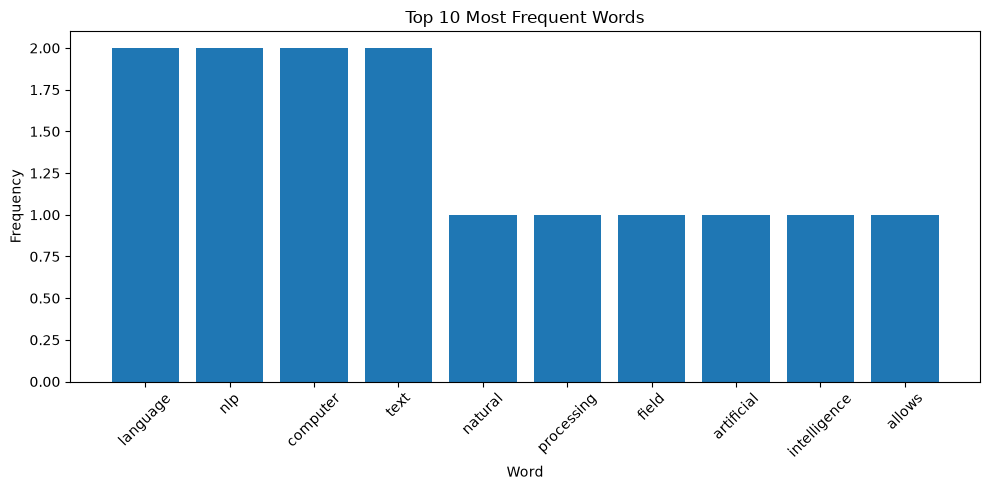

In [29]:
top_words = word_counts.most_common(10)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Words")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [30]:
raw_tokens = word_tokenize(text.lower())

no_stopwords = [
    token
    for token in raw_tokens
    if token.isalpha() and token not in stop_words
]

lemmatized = [
    lemmatizer.lemmatize(token)
    for token in no_stopwords
]

print("Raw tokens:", len(raw_tokens))
print("After cleaning:", len(no_stopwords))
print("After lemmatization:", len(lemmatized))

Raw tokens: 80
After cleaning: 45
After lemmatization: 45


In [33]:
documents = [
    "I love natural language processing.",
    "NLP is used in search engines.",
    "Machine learning is changing NLP.",
    "Text preprocessing is important for NLP.",
    "I enjoy building machine learning systems."
]

df = pd.DataFrame({
    "document": documents
})

df

,document
0,I love natural language processing.
1,NLP is used in search engines.
2,Machine learning is changing NLP.
3,Text preprocessing is important for NLP.
4,I enjoy building machine learning systems.


In [34]:
df["processed_tokens"] = df["document"].apply(preprocess)

df

,document,processed_tokens
0,I love natural language processing.,"[love, natural, language, processing]"
1,NLP is used in search engines.,"[nlp, used, search, engine]"
2,Machine learning is changing NLP.,"[machine, learning, changing, nlp]"
3,Text preprocessing is important for NLP.,"[text, preprocessing, important, nlp]"
4,I enjoy building machine learning systems.,"[enjoy, building, machine, learning, system]"


In [35]:
df["processed_text"] = df["processed_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

df

,document,processed_tokens,processed_text
0,I love natural language processing.,"[love, natural, language, processing]",love natural language processing
1,NLP is used in search engines.,"[nlp, used, search, engine]",nlp used search engine
2,Machine learning is changing NLP.,"[machine, learning, changing, nlp]",machine learning changing nlp
3,Text preprocessing is important for NLP.,"[text, preprocessing, important, nlp]",text preprocessing important nlp
4,I enjoy building machine learning systems.,"[enjoy, building, machine, learning, system]",enjoy building machine learning system
